# Temporal SHAP / TsSHAP for N-BEATS CO2 Forecasting

This notebook applies explainability to the existing N-BEATS workflow. It does not modify the original model files.

Run your N-BEATS notebook first, or run the setup cells here to recreate the required objects: `model`, `X_train`, `X_test`, `y_scaler`, `feature_cols`, and `input_size`.


(1924653, 21)
(1924649, 9)
(186889, 9)
(186889, 9)
(186884, 10)
(186884, 10)
(186884, 10)
                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -9.768571e+01  2.889048e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.849031e+01  1.018882e+02            0.0   
scd41_temperature      1.971432e+01  2.910343e+01            0.0   
scd41_humidity         8.847241e+00  6.352849e+01            0.0   
scd41_co2              2.501637e+02  7.448383e+02            0.0   
target_co2_15min       2.501637e+02  7.448383e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2 

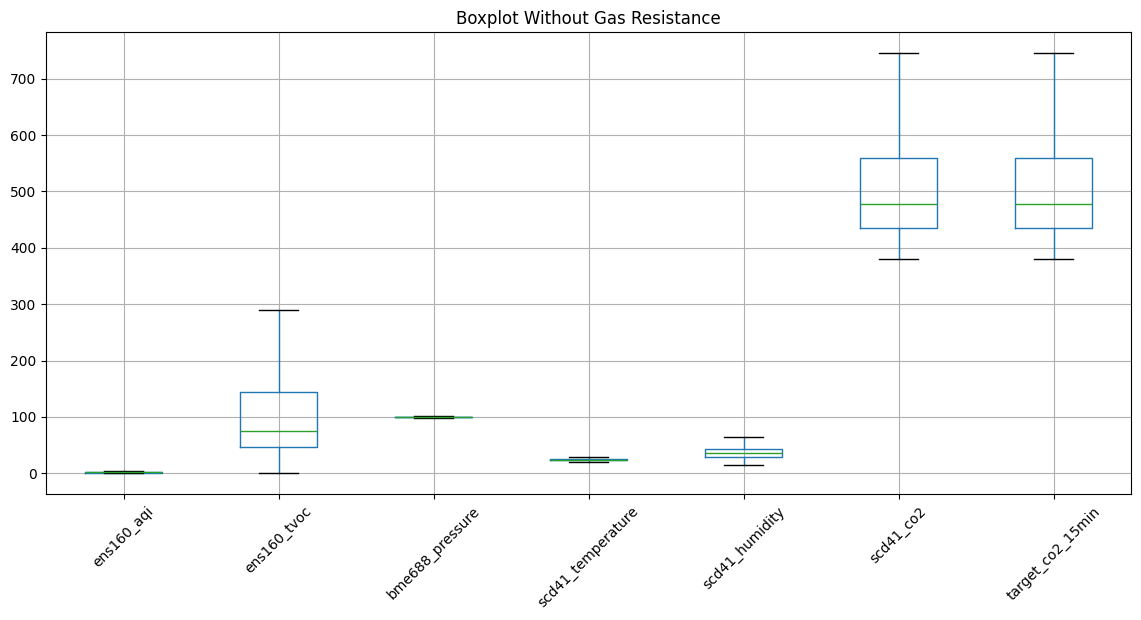

Train shape: (130816, 10)
Val shape: (28031, 10)
Test shape: (28037, 10)
Train percentage: 69.99850174439759
Val percentage: 14.999143853941483
Test percentage: 15.002354401660922

Rows per station:
            train   val  test
station_id                   
1           35269  7557  7559
2           13566  2907  2908
3           30913  6624  6625
4           30627  6563  6564
5           20441  4380  4381
Scaled X min/max: 0.0 1.0000000000000002
Scaled y min/max: 0.0 1.0000000000000002
X_train: (130516, 60, 8) y_train: (130516,)
X_val: (27731, 60, 8) y_val: (27731,)
X_test: (27737, 60, 8) y_test: (27737,)
Train batches: 2040
Val batches: 434
Test batches: 434
NBeats(
  (blocks): ModuleList(
    (0-1): 2 x NBeatsBlock(
      (fc): Sequential(
        (0): Linear(in_features=480, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=256, bias=True)
        (3): ReLU()
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5

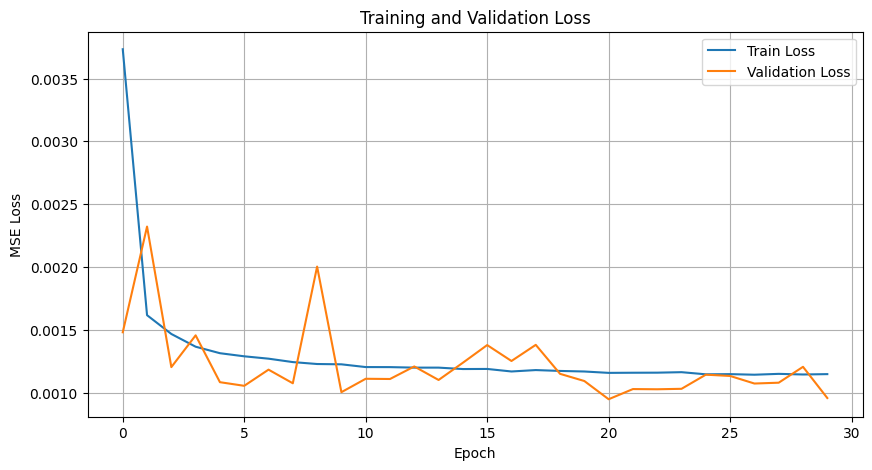

Metrics WITHOUT inverse scaling
MAE: 0.00935703981667757
MSE: 0.0004499706847127527
RMSE: 0.021212512456395934
R2: 0.9949978590011597
Predictions shape: (27737, 1)
Actuals shape: (27737, 1)
Metrics WITH inverse scaling
Test MAE: 3.4184792041778564
Test MSE: 60.0584602355957
Test RMSE: 7.749739365655835
Test R2: 0.9949978590011597


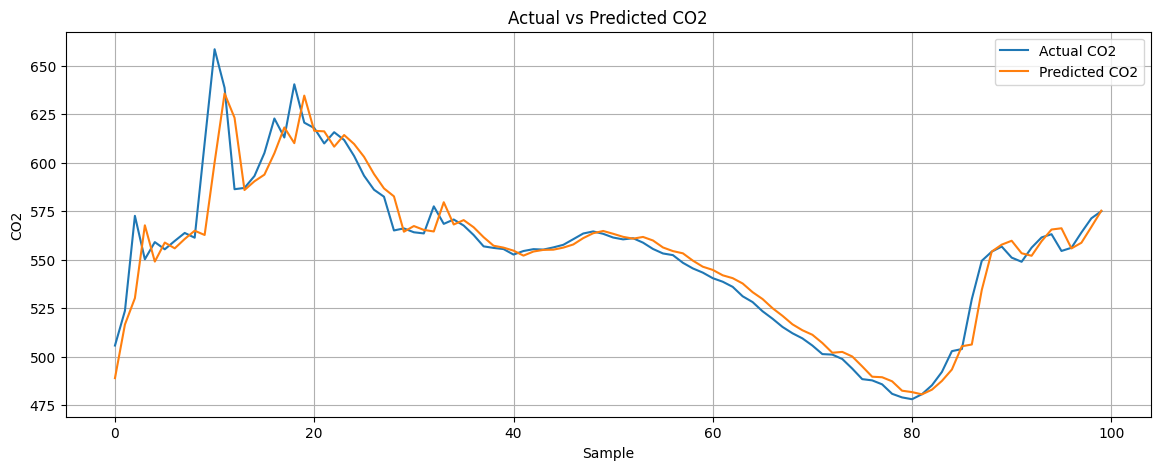

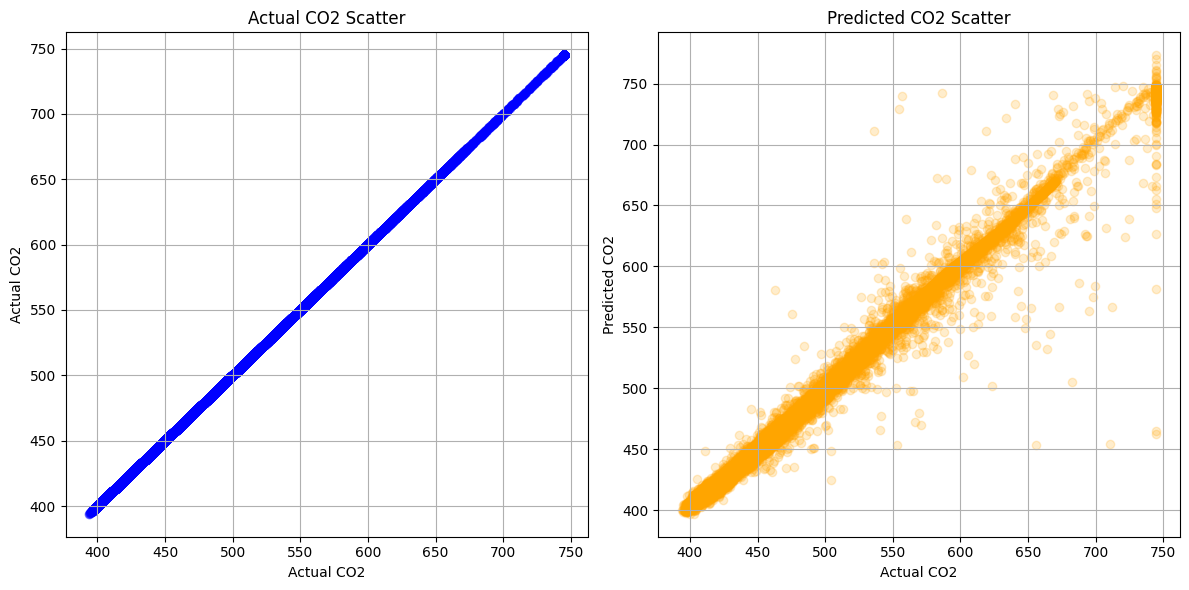

In [1]:
# Run the original N-BEATS notebook first.
# This keeps N_BEATS.ipynb unchanged and reuses its trained model and variables.
%run ./N_BEATS.ipynb

## Temporal SHAP / TsSHAP

These cells explain one test prediction. Change `sample_index` to explain another prediction.


In [2]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [3]:
model.eval()

# Use a small sample because SHAP is slow
# X_test shape should be: (samples, 60, num_features)
sample_index = 0

x_explain = X_test[sample_index:sample_index + 1]   # one sample to explain
baseline = X_train[np.random.choice(len(X_train), size=100, replace=False)].mean(axis=0)

print("x_explain shape:", x_explain.shape)
print("baseline shape:", baseline.shape)
print("features:", feature_cols)

x_explain shape: (1, 60, 8)
baseline shape: (60, 8)
features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2']


In [4]:
def predict_nbeats(x_numpy):
    """
    x_numpy shape: (n_samples, input_size, num_features)
    returns prediction in original CO2 scale
    """
    model.eval()

    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)

    with torch.no_grad():
        y_pred_scaled = model(x_tensor).cpu().numpy()

    y_pred_original = y_scaler.inverse_transform(y_pred_scaled)

    return y_pred_original[:, 0]

In [5]:
def temporal_mask_predictor(masks):
    """
    Each SHAP feature = one time step.
    If mask[t] = 1, keep original values at time t.
    If mask[t] = 0, replace that time step with baseline values.
    """
    masked_samples = []

    for mask in masks:
        x_masked = baseline.copy()

        for t in range(input_size):
            if mask[t] == 1:
                x_masked[t, :] = x_explain[0, t, :]

        masked_samples.append(x_masked)

    masked_samples = np.array(masked_samples)

    return predict_nbeats(masked_samples)

In [6]:
# Background masks for Kernel SHAP
# 0 = all baseline, 1 = all original
temporal_background = np.zeros((1, input_size))

temporal_explainer = shap.KernelExplainer(
    temporal_mask_predictor,
    temporal_background
)

temporal_shap_values = temporal_explainer.shap_values(
    np.ones((1, input_size)),
    nsamples=200
)

temporal_shap_values = np.array(temporal_shap_values).reshape(input_size)

print("Temporal SHAP shape:", temporal_shap_values.shape)

  0%|          | 0/1 [00:00<?, ?it/s]

Temporal SHAP shape: (60,)


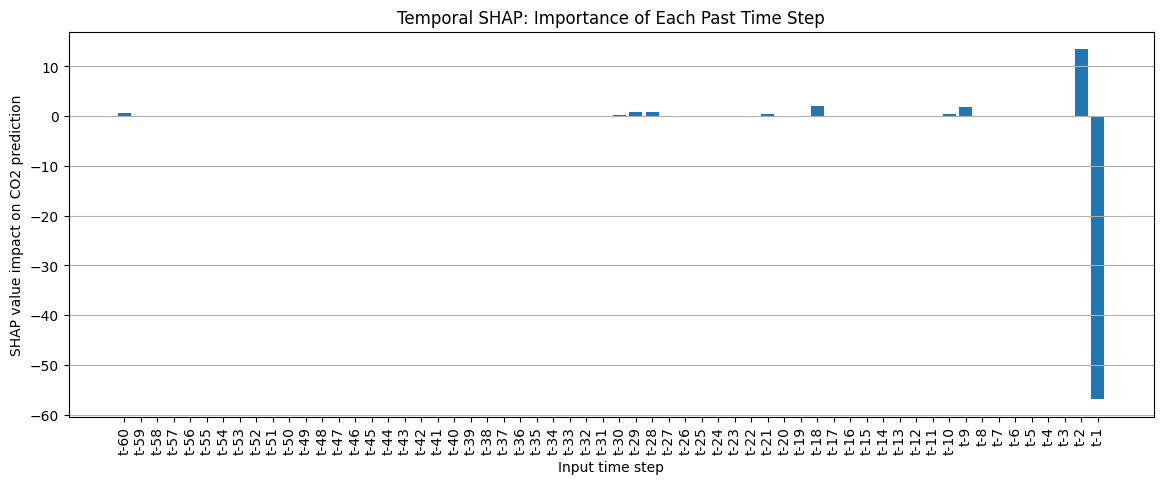

In [7]:
time_labels = [f"t-{input_size - i}" for i in range(input_size)]

plt.figure(figsize=(14, 5))
plt.bar(time_labels, temporal_shap_values)
plt.xticks(rotation=90)
plt.xlabel("Input time step")
plt.ylabel("SHAP value impact on CO2 prediction")
plt.title("Temporal SHAP: Importance of Each Past Time Step")
plt.grid(True, axis="y")
plt.show()

In [8]:
num_features = len(feature_cols)

def feature_mask_predictor(masks):
    """
    Each SHAP feature = one sensor feature across all 60 time steps.
    If mask[f] = 1, keep that feature's full temporal history.
    If mask[f] = 0, replace that feature with baseline.
    """
    masked_samples = []

    for mask in masks:
        x_masked = baseline.copy()

        for f in range(num_features):
            if mask[f] == 1:
                x_masked[:, f] = x_explain[0, :, f]

        masked_samples.append(x_masked)

    masked_samples = np.array(masked_samples)

    return predict_nbeats(masked_samples)

In [9]:
feature_background = np.zeros((1, num_features))

feature_explainer = shap.KernelExplainer(
    feature_mask_predictor,
    feature_background
)

feature_shap_values = feature_explainer.shap_values(
    np.ones((1, num_features)),
    nsamples=200
)

feature_shap_values = np.array(feature_shap_values).reshape(num_features)

feature_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "shap_value": feature_shap_values,
    "abs_shap_value": np.abs(feature_shap_values)
}).sort_values("abs_shap_value", ascending=False)

feature_importance_df

  0%|          | 0/1 [00:00<?, ?it/s]

,feature,shap_value,abs_shap_value
7,scd41_co2,-39.391137,39.391137
4,bme688_pressure,3.651805,3.651805
3,bme688_gas_resistance,-1.071385,1.071385
0,station_id,0.983302,0.983302
6,scd41_humidity,-0.845410,0.845410
5,scd41_temperature,0.650485,0.650485
1,ens160_aqi,-0.158379,0.158379
2,ens160_tvoc,-0.084173,0.084173


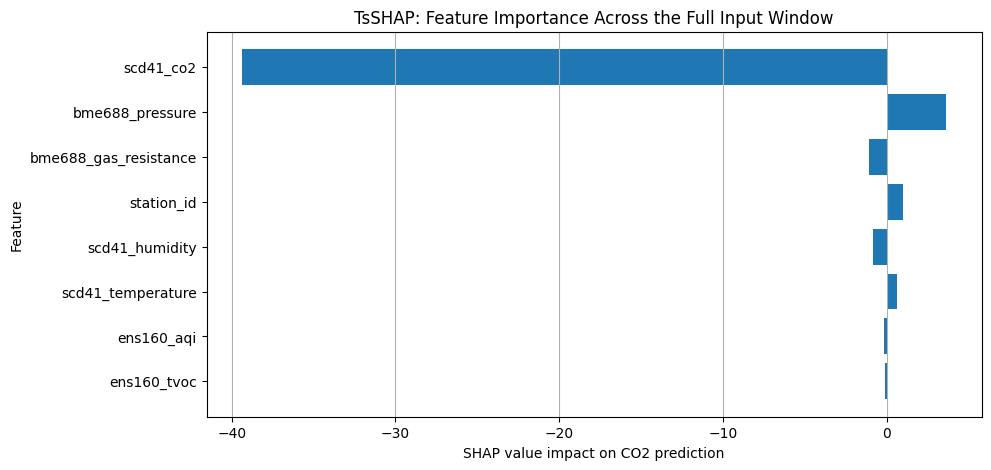

In [10]:
plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["shap_value"]
)
plt.xlabel("SHAP value impact on CO2 prediction")
plt.ylabel("Feature")
plt.title("TsSHAP: Feature Importance Across the Full Input Window")
plt.gca().invert_yaxis()
plt.grid(True, axis="x")
plt.show()

## Optional: Time Step x Feature Heatmap

This is more expensive because SHAP treats every `(time step, feature)` pair as a separate explainability group. Start with a low `nsamples` value, then increase it if needed.


In [11]:
def time_feature_mask_predictor(masks):
    """
    Each SHAP feature = one cell: one time step + one sensor feature.
    This is more expensive because dimension = input_size * num_features.
    """
    masked_samples = []

    for mask in masks:
        x_masked = baseline.copy()
        mask_2d = mask.reshape(input_size, num_features)

        x_masked[mask_2d == 1] = x_explain[0][mask_2d == 1]

        masked_samples.append(x_masked)

    masked_samples = np.array(masked_samples)

    return predict_nbeats(masked_samples)

In [12]:
num_time_feature_groups = input_size * num_features

time_feature_background = np.zeros((1, num_time_feature_groups))

time_feature_explainer = shap.KernelExplainer(
    time_feature_mask_predictor,
    time_feature_background
)

time_feature_shap_values = time_feature_explainer.shap_values(
    np.ones((1, num_time_feature_groups)),
    nsamples=300
)

time_feature_shap_values = np.array(time_feature_shap_values).reshape(input_size, num_features)

print("Time-feature SHAP shape:", time_feature_shap_values.shape)

  0%|          | 0/1 [00:00<?, ?it/s]

Time-feature SHAP shape: (60, 8)


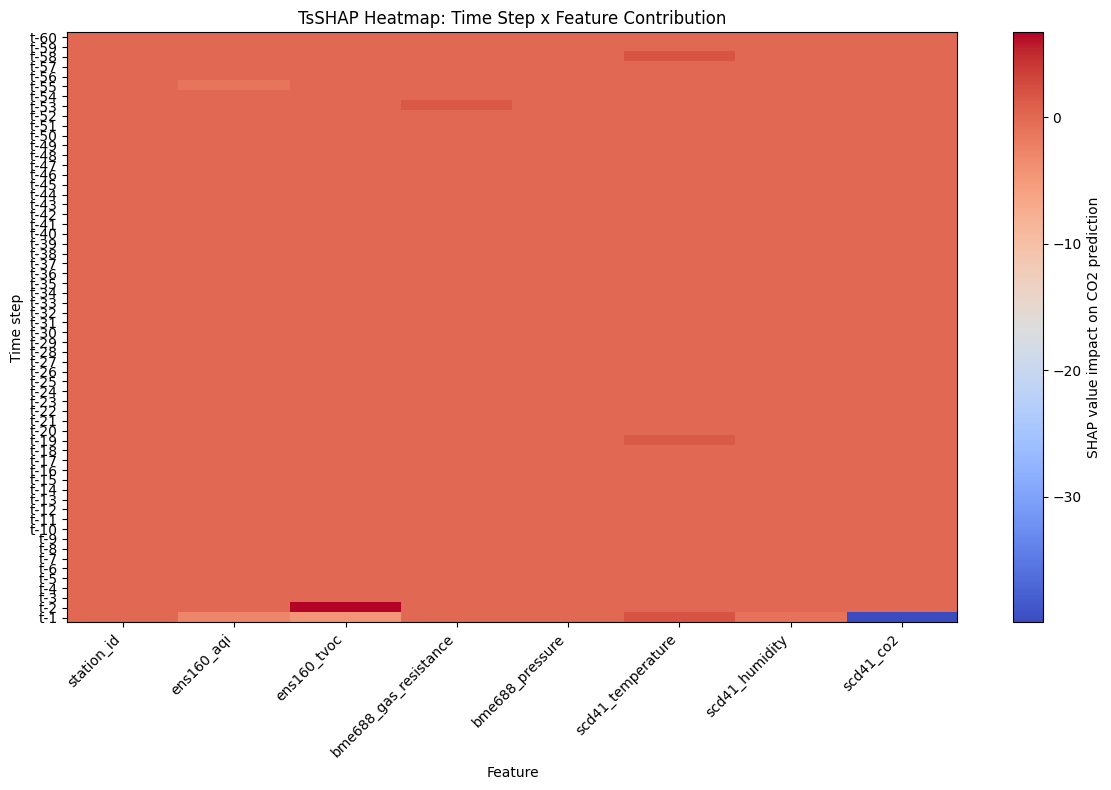

In [13]:
plt.figure(figsize=(12, 8))

plt.imshow(
    time_feature_shap_values,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="SHAP value impact on CO2 prediction")
plt.xticks(range(num_features), feature_cols, rotation=45, ha="right")
plt.yticks(range(input_size), time_labels)

plt.xlabel("Feature")
plt.ylabel("Time step")
plt.title("TsSHAP Heatmap: Time Step x Feature Contribution")

plt.tight_layout()
plt.show()

## Interpretation

Positive SHAP values push the predicted CO2 higher. Negative SHAP values push the predicted CO2 lower. Larger absolute values mean stronger influence on the prediction.
